<div align="center">
  <a href="https://colab.research.google.com/github/PrunaAI/ai-efficiency-courses/blob/main/solutions/01-analyze_llm_architectures.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

---
**💡 Tip**: Click the button above to open this notebook in Google Colab for free GPU access!

## Installation

This notebook includes automatic setup cells that will install the project from git repository with UV.

**Note**: Run the setup cells below before starting the exercises.

In [ ]:
# Install project directly from git repository
!uv pip install git+https://github.com/PrunaAI/ai-efficiency-courses.git

# 01: Analyze LLM Architectures

Welcome to the first lecture of the AI Efficiency course! 🚀

In this tutorial, we will take a deep dive into the internal architecture of Large Language Models (LLMs). Understanding the building blocks of LLMs is crucial for anyone working with these models—whether you want to debug, optimize, or simply gain a deeper appreciation for how they work.

By the end of this lecture, you will:
- Understand the key components that make up modern LLMs.
- Learn how to inspect and analyze model architectures programmatically.
- Gain practical skills for evaluating model capabilities and limitations.

Let's get started on unraveling the inner workings of LLMs!

## 1. Imports

As we've already installed the project, we can import the necessary libraries. We will be using `torch` and `transformers` for this tutorial as interfaces to the model and tokenizer. On top of that, we will be using `matplotlib` for basic plotting. 

Beyond external libraries, this course comes with the `course` local package which contains a lot of utils that you can use in the notebooks.

In [1]:
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

## 2. Utils

In this section, we'll leverage some course utilities to streamline our workflow.
These utilities will help us:
- Load and manage lists of model ids that we have verified to work.
- Generate informative plots for model analysis.
- Iterate efficiently over evaluation and model configuration options.

Let's first load our models. We will use `SMALL_MODEL_IDS`, which are sub 1B parameters which should be easy to download and load into memory. We recommend starting with these smaller models but feel free to experiment with other models until you reach your GPU memory limit! 

In [2]:
from course import SMALL_MODEL_IDS as MODEL_IDS
# from course import MEDIUM_MODEL_IDS as MODEL_IDS
# from course import LARGE_MODEL_IDS as MODEL_IDS

MODEL_IDS

['facebook/opt-125m',
 'facebook/opt-350m',
 'HuggingFaceTB/SmolLM-135M-instruct',
 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'HuggingFaceTB/SmolLM-360M-Instruct',
 'HuggingFaceTB/SmolLM2-360M-Instruct',
 'PleIAs/Pleias-350m-Preview',
 'PleIAs/Pleias-Pico',
 'LiquidAI/LFM2-350M',
 'LiquidAI/LFM2-700M']

Now, let's take a look at our plotting functions. We can use the `create_single_plot` function to create a single plot or use `create_multiple_plots` with a list of dictionaries to create a raster of plots.

In [3]:
from course.plots import create_single_plot

create_single_plot(
    data_dict={"a": 1, "b": 2, "c": 3}, x_label="X", y_label="Y", title="Single Plot"
)

## 3. Analyze LLM architectures

### 3.1 Exploring General LLM Model Information

In this section, you'll learn how to systematically extract and interpret the core architectural properties of large language models (LLMs).

**Why is this important?**
Understanding the structure of an LLM—such as its hidden size, number of layers, and vocabulary size—helps you reason about its capabilities, memory requirements, and potential performance. These attributes are foundational for comparing models and making informed choices for downstream tasks.

**Your tasks:**
1. **Implement the `get_model_info` function:**  
    Write a function that takes a loaded LLM model and returns a dictionary with its key architectural details.
2. **Apply your function to multiple models:**  
    Use your function to extract and compare information from several LLMs. This will help you see how different design choices manifest across models.

**Key questions to answer as you explore:**
- What is the hidden size of the model? (This determines the dimensionality of the model's internal representations.)
- How many attention heads does it use? (Each head compute different attention between input tokens.)
- How many layers and blocks are there? (Deeper models can often capture more complex patterns.)
- What is the vocabulary size? (Elements of the vocabulary are tokens that the model can represent directly.)
- What is the architecture class? (E.g., "OPTForCausalLM", "LlamaForCausalLM", etc.)
- What is the maximum context length? (How many tokens can the model process at once?)

As you complete this section, reflect on how these properties might influence the model's strengths, weaknesses, and resource requirements.

In [ ]:
model_id = MODEL_IDS[0]
model = AutoModelForCausalLM.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model, tokenizer

(OPTForCausalLM(
   (model): OPTModel(
     (decoder): OPTDecoder(
       (embed_tokens): Embedding(50272, 768, padding_idx=1)
       (embed_positions): OPTLearnedPositionalEmbedding(2050, 768)
       (final_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
       (layers): ModuleList(
         (0-11): 12 x OPTDecoderLayer(
           (self_attn): OPTAttention(
             (k_proj): Linear(in_features=768, out_features=768, bias=True)
             (v_proj): Linear(in_features=768, out_features=768, bias=True)
             (q_proj): Linear(in_features=768, out_features=768, bias=True)
             (out_proj): Linear(in_features=768, out_features=768, bias=True)
           )
           (activation_fn): ReLU()
           (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
           (fc1): Linear(in_features=768, out_features=3072, bias=True)
           (fc2): Linear(in_features=3072, out_features=768, bias=True)
           (final_layer_norm): L

Now, let's implement the `get_model_info` function.

In [ ]:
def get_model_info(model):
    """
    Returns basic information about the loaded LLM model.

    Args:
        model: The loaded model

    Returns:
        dict: Dictionary containing model information
    """
    
    ### To Complete ###
    model_config = model.config
    info = {
        "hidden_size": model_config.hidden_size,
        "num_attention_heads": model_config.num_attention_heads,
        "num_hidden_layers": model_config.num_hidden_layers,
        "vocab_size": model_config.vocab_size,
        "model_type": model_config.model_type,
        "architecture": type(model).__name__,
        "max_context_length": model_config.max_position_embeddings,
    }
    ### End of To Complete ###
    return info


model_info = get_model_info(model)
model_info

{'hidden_size': 768,
 'num_attention_heads': 12,
 'num_hidden_layers': 12,
 'vocab_size': 50272,
 'model_type': 'opt',
 'architecture': 'OPTForCausalLM',
 'max_context_length': 2048}

### 3.2 Investigating Tokenization Behavior

Next, you'll explore how tokenizers process input text, especially when the text contains typos or other variations.

**Why is this important?**
Tokenization is the process of converting text into a sequence of tokens, which are the basic units of text that the model can process. Understanding how tokenizers handle typos or other input variations is crucial for ensuring that the model receives the correct input and for improving the model's quality and efficiency.    

**Your tasks:**
1. Use the tokenizer to encode both a correctly spelled sentence and a version with typos (or other input variations).
2. Repeat this process for several different LLMs to observe any differences.

**Key questions to consider as you experiment:**
- In what ways do typos or mistakes in the input sentence affect the resulting tokenization?
- How might these tokenization differences influence the model's downstream performance?

Now, let's implement the code to answer the questions.

In [7]:
# Test sentences - one with typos and one without
correct_sentence = "The quick brown fox jumps over the lazy dog."
typo_sentence = "Teh quik brwn fox jmps ovr the lzy dog."

### To Complete ###
tokens_correct = tokenizer(correct_sentence, return_tensors="pt")
tokens_typo = tokenizer(typo_sentence, return_tensors="pt")

print("Correct sentence tokens:")
print(tokenizer.convert_ids_to_tokens(tokens_correct["input_ids"][0]))
print("\nTypo sentence tokens:")
print(tokenizer.convert_ids_to_tokens(tokens_typo["input_ids"][0]))
### End of To Complete ###

Correct sentence tokens:
['</s>', 'The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']

Typo sentence tokens:
['</s>', 'Te', 'h', 'Ġqu', 'ik', 'Ġbr', 'wn', 'Ġfox', 'Ġj', 'm', 'ps', 'Ġov', 'r', 'Ġthe', 'Ġl', 'zy', 'Ġdog', '.']


### 3.3 Exploring LLM Module Composition

In this section, you'll systematically analyze the internal building blocks ("modules") that make up a large language model (LLM).

**Why is this important?**
Understanding the types and counts of modules within an LLM helps you reason about its computational structure, memory footprint, and the architectural patterns that enable its capabilities. This knowledge is foundational for model comparison, optimization, and interpretability.

**Your tasks:**
1. **Implement a module counting utility:**  
   Write a function (or class) that traverses a loaded LLM and returns a count of each unique module type it contains.
2. **Apply your utility to multiple models:**  
   Use your function to extract and compare module statistics across several LLMs. This will help you observe architectural similarities and differences.

**Key questions to answer as you explore:**
- What is the role of each module type in the model's computation?
- Which modules appear only once, and why might that be?
- Which modules are repeated many times, and what does this suggest about the model's design?
- Which module type is the most common, and what does this reveal about the model's dominant operations?

Now, let's implement the code to answer the questions.

In [ ]:
def count_modules(model):
    """Count the number of each type of module in the model.

    Args:
        model: The PyTorch model to analyze

    Returns:
        dict: A dictionary mapping module type names to their counts
    """
    module_counts = {}
    
    ### To Complete ###
    for _, module in model.named_modules():
        module_type = type(module).__name__
        module_counts[module_type] = module_counts.get(module_type, 0) + 1
    ### End of To Complete ###
    return module_counts


module_counts = count_modules(model)
create_single_plot(
    module_counts,
    x_label="Module Type",
    y_label="Count",
    title="Count of Different Module Types",
)

### 3.4 Exploring LLM Parameter Distribution

In this section, you'll systematically analyze the parameter distribution across different module types within a large language model (LLM).

**Why is this important?**
Understanding how parameters are distributed among module types helps you reason about the model's memory usage, computational hotspots, and architectural design choices. This insight is crucial for model optimization, interpretability, and efficient deployment.

**Your tasks:**
1. **Implement a parameter counting utility:**  
   Write a class-based utility that traverses a loaded LLM and returns a count of parameters for each unique module type it contains.
2. **Apply your utility to multiple models:**  
   Use your class to extract and compare parameter statistics across several LLMs. This will help you observe architectural similarities and differences.

**Key questions to answer as you explore:**
- Which modules have the least parameters, and why? What does this suggest about their efficiency impact?
- Which modules have the most parameters, and why? What does this suggest about their efficiency impact?
- What is the parameter count for each module type?
- Which layer type dominates the parameter count, and what does this reveal about the model's design?

Let's implement the code to answer the questions.

In [ ]:
def count_module_parameters(model):
    """Count the number of parameters in each module type in the model.

    Args:
        model: The PyTorch model to analyze

    Returns:
        dict: A dictionary mapping module type names to their total parameter counts
    """
    module_parameters = {}
    
    ### To Complete ###
    for _, module in model.named_modules():
        module_type = type(module).__name__
        num_params = sum(p.numel() for p in module.parameters())
        module_parameters[module_type] = (
            module_parameters.get(module_type, 0) + num_params
        )
    ### End of To Complete ###
    return module_parameters


module_parameters = count_module_parameters(model)
create_single_plot(
    module_parameters,
    x_label="Module Type",
    y_label="Number of Parameters",
    title="Number of Parameters per Module Type",
)

Now, you'll systematically analyze the precision (dtype) of parameters across different module types within a large language model (LLM).

**Why is this important?**
Understanding the precision of parameters in each module type helps you reason about the model's memory usage, numerical stability, and potential for quantization or mixed-precision optimization. This insight is crucial for efficient deployment and hardware compatibility.

**Your tasks:**
1. **Implement a parameter precision analysis utility:**  
   Write a class-based utility that traverses a loaded LLM and returns the precision (dtype) of parameters for each unique module type that contains parameters.
2. **Apply your utility to multiple models:**  
   Use your class to extract and compare parameter precision statistics across several LLMs. This will help you observe architectural similarities and differences in precision usage.

**Key questions to answer as you explore:**
- What is the precision of the parameters in each module?
- Are there modules with mixed precision, and what might this indicate?
- How does parameter precision vary across different LLM architectures?

In [ ]:
def get_module_precisions(model):
    """
    Returns a dictionary mapping module types to their parameter precision/dtype.

    Args:
        model: PyTorch model

    Returns:
        dict: Mapping of module type names to their parameter dtype
    """
    module_dtypes = {}
    
    ### To Complete ###
    for _, module in model.named_modules():
        if list(module.parameters()):  # Only check modules with parameters
            module_type = type(module).__name__
            dtype = next(module.parameters()).dtype
            if module_type not in module_dtypes:
                if module_type in module_dtypes and module_dtypes[module_type] != dtype:
                    print(
                        f"Warning: Mixed precision detected for {module_type} - found both {module_dtypes[module_type]} and {dtype}"
                    )
                module_dtypes[module_type] = dtype
    ### End of To Complete ###
    return module_dtypes


module_precisions = get_module_precisions(model)
for module_type, dtype in module_precisions.items():
    print(f"- {module_type} parameters dtype: {dtype}")

- OPTForCausalLM parameters dtype: torch.float32
- OPTModel parameters dtype: torch.float32
- OPTDecoder parameters dtype: torch.float32
- Embedding parameters dtype: torch.float32
- OPTLearnedPositionalEmbedding parameters dtype: torch.float32
- LayerNorm parameters dtype: torch.float32
- ModuleList parameters dtype: torch.float32
- OPTDecoderLayer parameters dtype: torch.float32
- OPTAttention parameters dtype: torch.float32
- Linear parameters dtype: torch.float32


As we saw in the previous section, the number of parameters in a model of a model can be misleading as it only looks at the number of parameters in the model, but not the precision of the parameters. We will continue with the same model, and we will explore how to estimate the memory footprint of a model based on the precision and number of parameters of each module.

**Your tasks:**
1. **Implement a memory estimation utility:**  
   Write a class-based utility that takes both the parameter count and the precision (dtype) for each module type, and estimates the memory footprint of the model.
2. **Apply your utility to multiple models:**  
   Use your class to extract and compare memory usage statistics across several LLMs. This will help you observe how memory requirements differ based on architecture and precision.

**Key questions to answer as you explore:**
- What is the estimated memory footprint of each module type, given its parameter count and precision?
- What is the total estimated memory footprint of the model?
- What are the limitations or assumptions of this estimation approach?

In [ ]:
def estimate_memory_footprint(module_parameters, module_precisions):
    """
    Estimates the memory footprint of a model based on parameter counts and precisions.

    Args:
        module_parameters: Dict mapping module types to parameter counts
        module_precisions: Dict mapping module types to parameter dtypes

    Returns:
        dict: Memory usage in bytes for each module type
        float: Total memory usage in bytes
    """
    
    ### To Complete ###
    dtype_sizes = {
        torch.float16: 2,  # 16-bit = 2 bytes
        torch.float32: 4,  # 32-bit = 4 bytes
        torch.float64: 8,  # 64-bit = 8 bytes
        torch.int8: 1,  # 8-bit = 1 byte
        torch.int16: 2,  # 16-bit = 2 bytes
        torch.int32: 4,  # 32-bit = 4 bytes
        torch.int64: 8,  # 64-bit = 8 bytes
    }

    memory_usage = {}
    total_memory = 0

    for module_type in module_parameters:
        if module_type in module_precisions:
            dtype = module_precisions[module_type]
            num_params = module_parameters[module_type]
            bytes_per_param = dtype_sizes.get(
                dtype, 4
            )  # Default to 4 bytes if dtype not found
            memory = num_params * bytes_per_param
            memory_usage[module_type] = memory
            total_memory += memory
    ### End of To Complete ###
    return memory_usage, total_memory


estimate_memory_footprint(module_parameters, module_precisions)

({'OPTForCausalLM': 500957184,
  'OPTModel': 500957184,
  'OPTDecoder': 500957184,
  'Embedding': 154435584,
  'OPTLearnedPositionalEmbedding': 6297600,
  'LayerNorm': 153600,
  'ModuleList': 340217856,
  'OPTDecoderLayer': 340217856,
  'OPTAttention': 113393664,
  'Linear': 494505984},
 2952093696)

Besides weights, we can also visualize the internal structure of model parameters when it comes to the initialization of the parameter weights. The initialization of the parameters is a crucial step in the training process, and it can be used to control the model's behavior. Therefore, it is important to understand how the parameters are initialized and to learn if we can find any patterns in the initialization of the parameters.

**Your tasks:**
1. **Implement a parameter visualization utility:**  
   Write a class-based utility that, given a model and a module name, generates:
   - A heatmap of the absolute values of the parameters.
   - A distribution plot (histogram) of the parameter values.

2. **Apply your utility to multiple LLMs:**  
   Use your class to extract and compare parameter visualizations across several LLMs. This will help you observe whether there are any patterns in the parameter initialization or learned weights.

**Key questions to answer as you explore:**
- Does the parameter heatmap show any patterns or structure?
- Does the parameter distribution reveal any interesting characteristics?

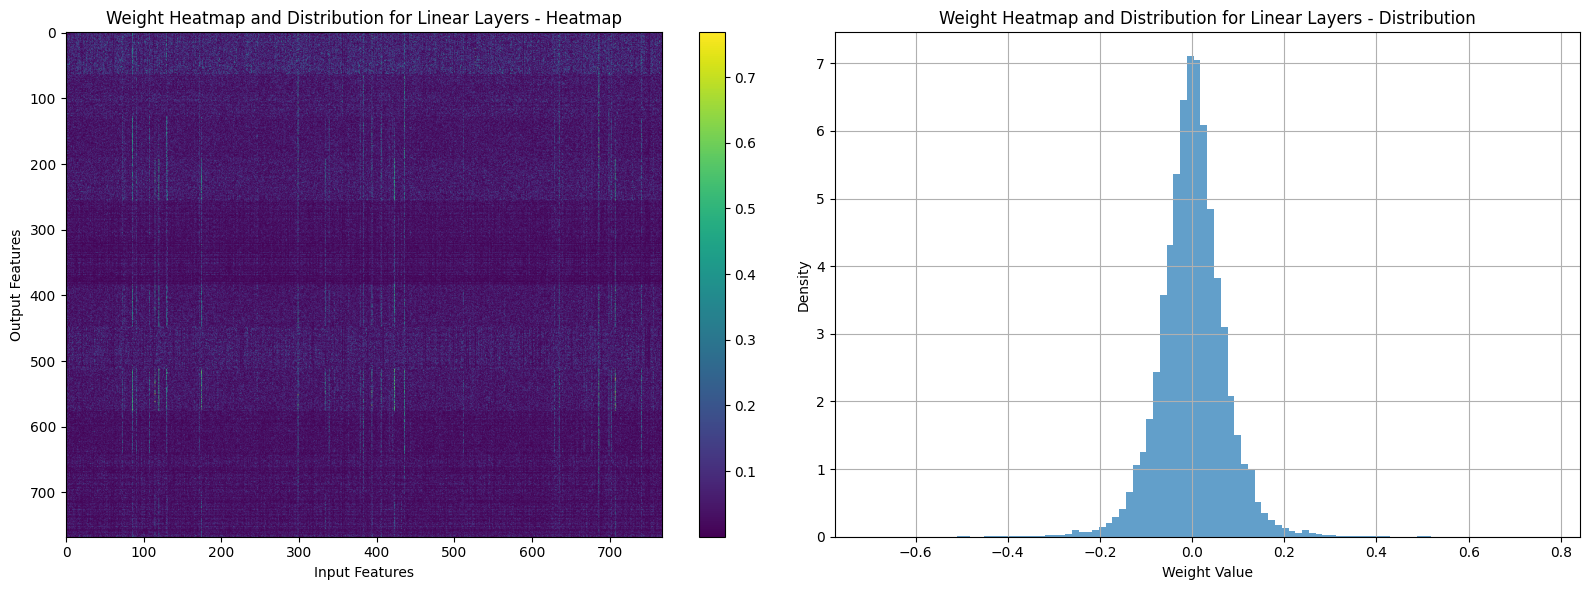

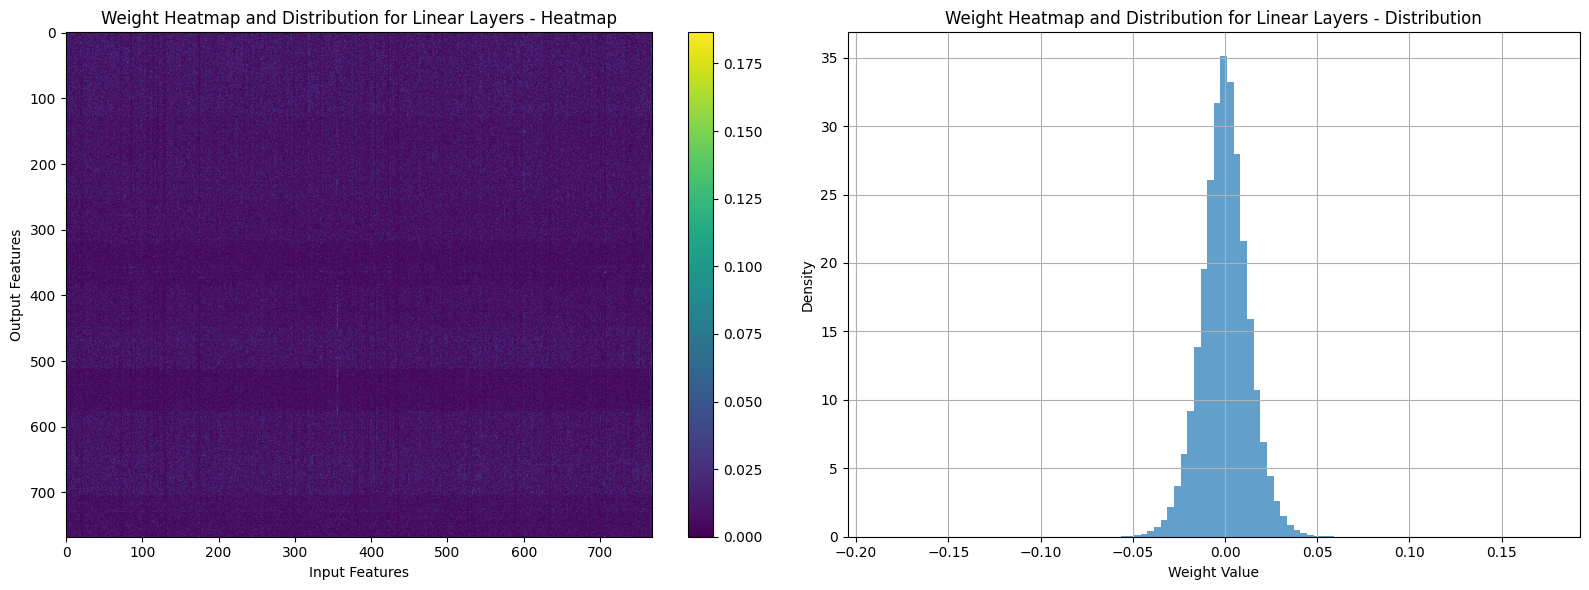

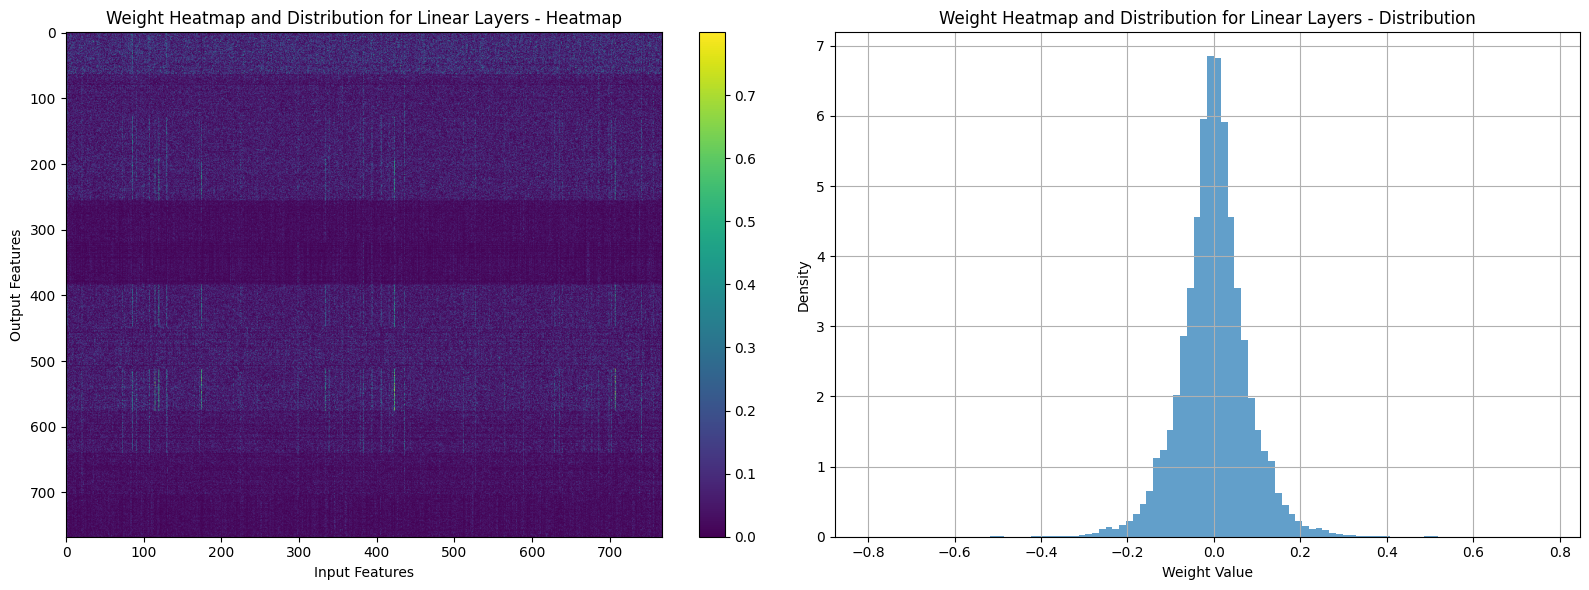

In [ ]:
def plot_weight_heatmap_and_distribution(
    model, module_name: str, title: str = None
) -> None:
    """
    Plot side-by-side the heatmap of absolute weight values and the distribution of weights
    for a specific module in the model.

    Args:
        model: PyTorch model
        module_name: Name of the module to analyze
        title: Optional title for the plot
    """
    
    ### To Complete ###
    import matplotlib.pyplot as plt
    import numpy as np

    for name, module in model.named_modules():
        if name == module_name and hasattr(module, "weight"):
            # Extract weights
            weights = module.weight.detach().cpu().numpy()
            abs_weights = np.abs(weights)
            flat_weights = weights.flatten()

            # Create side-by-side plots
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))

            # Heatmap of absolute weights
            im = axes[0].imshow(abs_weights, cmap="viridis", aspect="auto")
            plt.colorbar(im, ax=axes[0])
            axes[0].set_title(
                (title + " - Heatmap") if title else f"Weight Heatmap for {name}"
            )
            axes[0].set_xlabel("Input Features")
            axes[0].set_ylabel("Output Features")

            # Distribution of weights
            axes[1].hist(
                flat_weights, bins=100, density=True, color="tab:blue", alpha=0.7
            )
            axes[1].set_title(
                (title + " - Distribution")
                if title
                else f"Distribution of Weights in {name}"
            )
            axes[1].set_xlabel("Weight Value")
            axes[1].set_ylabel("Density")
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()
            break
    ### End of To Complete ###


for i, (name, module) in enumerate(model.named_modules()):
    if isinstance(module, torch.nn.Linear):
        plot_weight_heatmap_and_distribution(
            model, name, title="Weight Heatmap and Distribution for Linear Layers"
        )
    if i > 10:
        break

### 3.5 Analyzing LLM Activations

In this section, you'll systematically investigate the activations produced by large language models (LLMs) in response to specific input sentences.

**Why is this important?**
Examining the activations at various layers provides insight into how information is processed and transformed throughout the model. This understanding is crucial for interpreting model behavior, diagnosing issues, and optimizing architectures for efficiency and performance.

**Your tasks:**
1. **Implement an activation collection utility:**  
   Write a class-based utility that processes a given input sentence through a loaded LLM and records the activations at each relevant layer.
2. **Apply your utility to multiple models:**  
   Use your class to extract and compare activation statistics across several LLMs. This will help you observe how different architectures represent and propagate information.

**Key questions to answer as you explore:**
- What is the shape of the activations at each layer?
- How do activation patterns differ between models and layers?
- What do these differences suggest about the models' internal representations?

Now, let's implement the code to answer the questions.

In [ ]:
def collect_activations(model, tokenizer, prompt):
    """
    Collect activation values when processing an input prompt through the model.

    Args:
        model: PyTorch model
        tokenizer: Tokenizer
        prompt: Input text prompt

    Returns:
        Dictionary mapping layer names to their activation values
    """
    activations = {}

    ### To Complete ###
    # Hook function to capture activations
    def hook_fn(name):
        def hook(module, input, output):
            activations[name] = (
                output.detach().cpu()
            )  # Shape: (batch_size, sequence_length, hidden_size)

        return hook

    # Register hooks for all modules
    handles = []
    for name, module in model.named_modules():
        if isinstance(module, (torch.nn.Linear, torch.nn.LayerNorm)):
            handle = module.register_forward_hook(hook_fn(name))
            handles.append(handle)

    # Process input through model
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        model(**inputs)

    # Remove hooks
    for handle in handles:
        handle.remove()
    ### End of To Complete ###
    return activations


prompt = "Hello, how are you?"
layer_activations = collect_activations(model, tokenizer, prompt)
# Print activation shapes for each layer
for name, activation in layer_activations.items():
    print(f"{name}: {activation.shape}")

model.decoder.layers.0.self_attn_layer_norm: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.q_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.k_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.v_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.self_attn.out_proj: torch.Size([1, 7, 768])
model.decoder.layers.0.final_layer_norm: torch.Size([7, 768])
model.decoder.layers.0.fc1: torch.Size([7, 3072])
model.decoder.layers.0.fc2: torch.Size([7, 768])
model.decoder.layers.1.self_attn_layer_norm: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.q_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.k_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.v_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.self_attn.out_proj: torch.Size([1, 7, 768])
model.decoder.layers.1.final_layer_norm: torch.Size([7, 768])
model.decoder.layers.1.fc1: torch.Size([7, 3072])
model.decoder.layers.1.fc2: torch.Size([7, 768])
model.decoder.la

Now that we can collect the activations of the model, it's valuable to visualize the internal structure of these activations produced by LLMs in response to different inputs. Understanding the distribution and structure of these activations can provide insights into how information is processed within the model.

**Your tasks:**
1. **Develop an activation visualization utility:**  
   Create a class-based utility that, given a model, a module name, and an input prompt, generates:
   - A heatmap of the absolute values of the activations.
   - A distribution plot (histogram) of the activation values.

2. **Apply your utility to multiple LLMs and input prompts:**  
   Use your class to extract and compare activation visualizations across several LLMs and a variety of input sentences. This will help you observe whether there are any consistent patterns in the activations or notable differences between models or prompts.

**Key questions to consider as you explore:**
- Do the activation heatmaps reveal any structure or recurring patterns?
- Does the distribution of activation values show any interesting characteristics or trends?

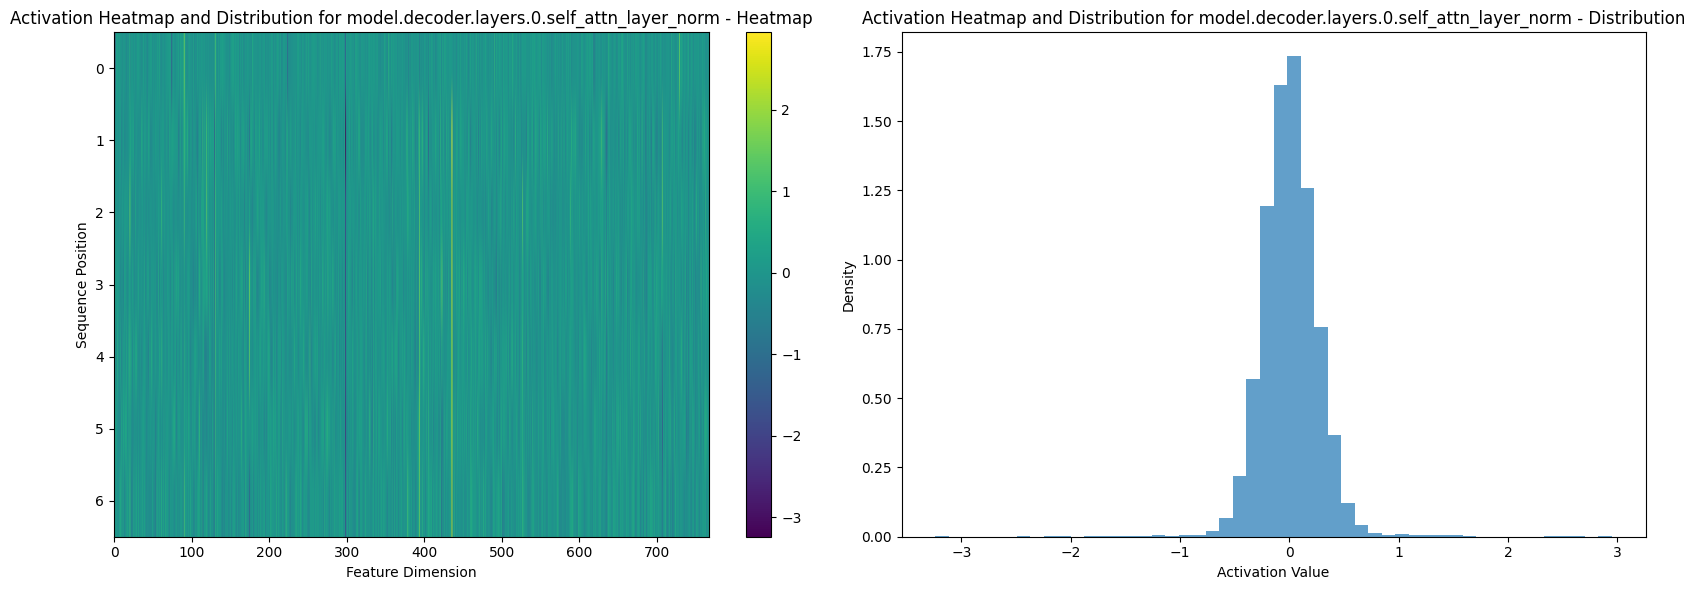

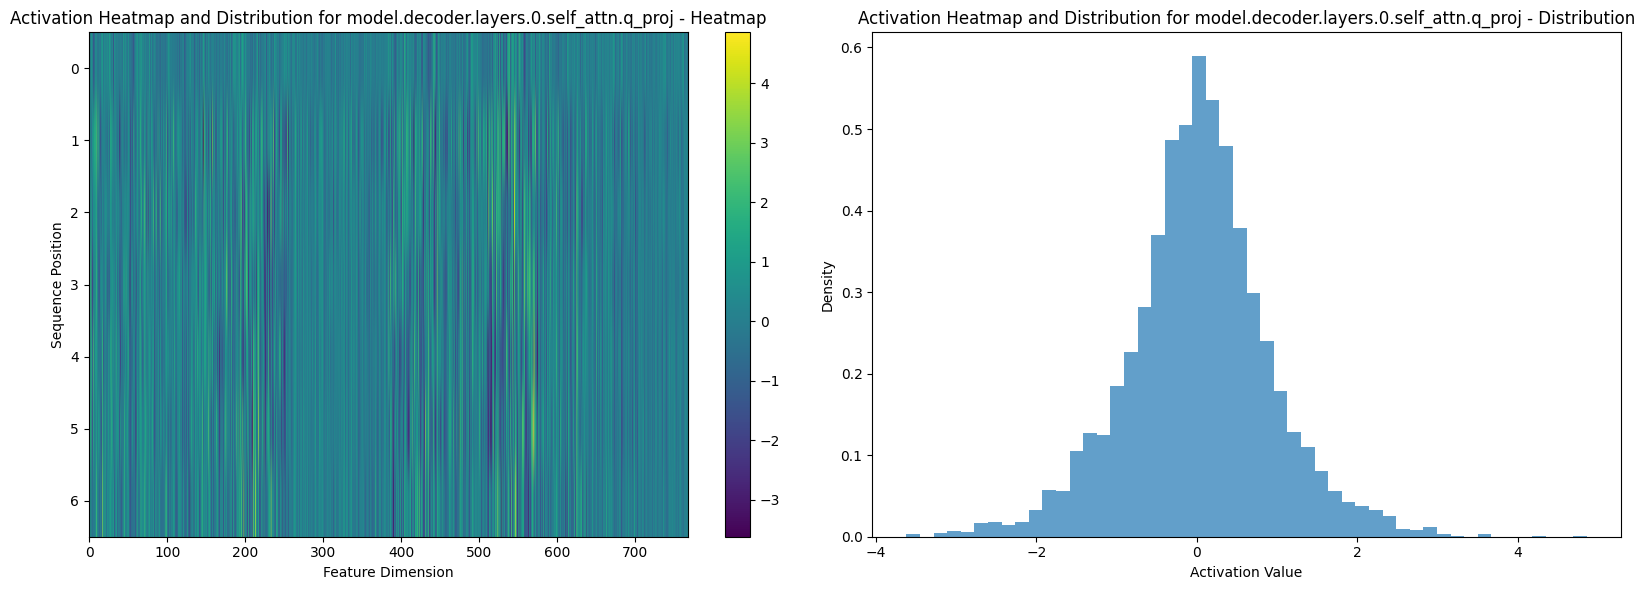

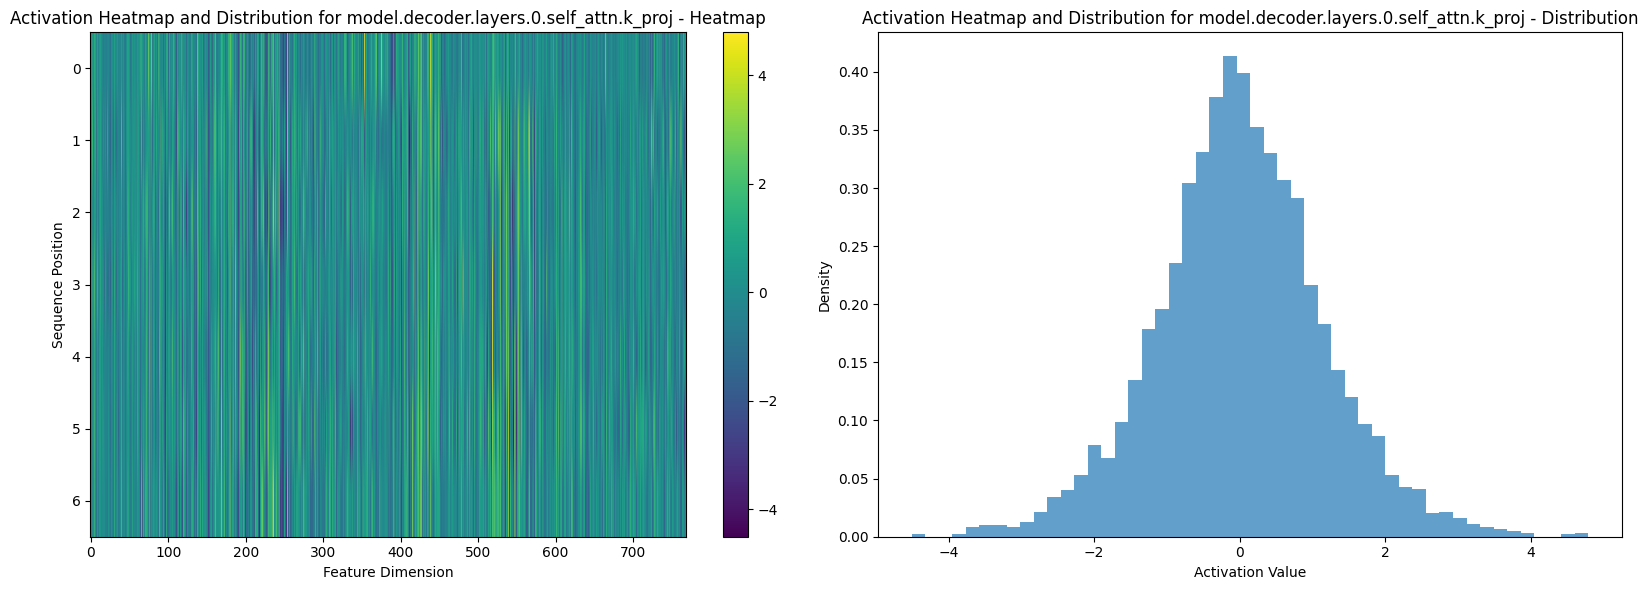

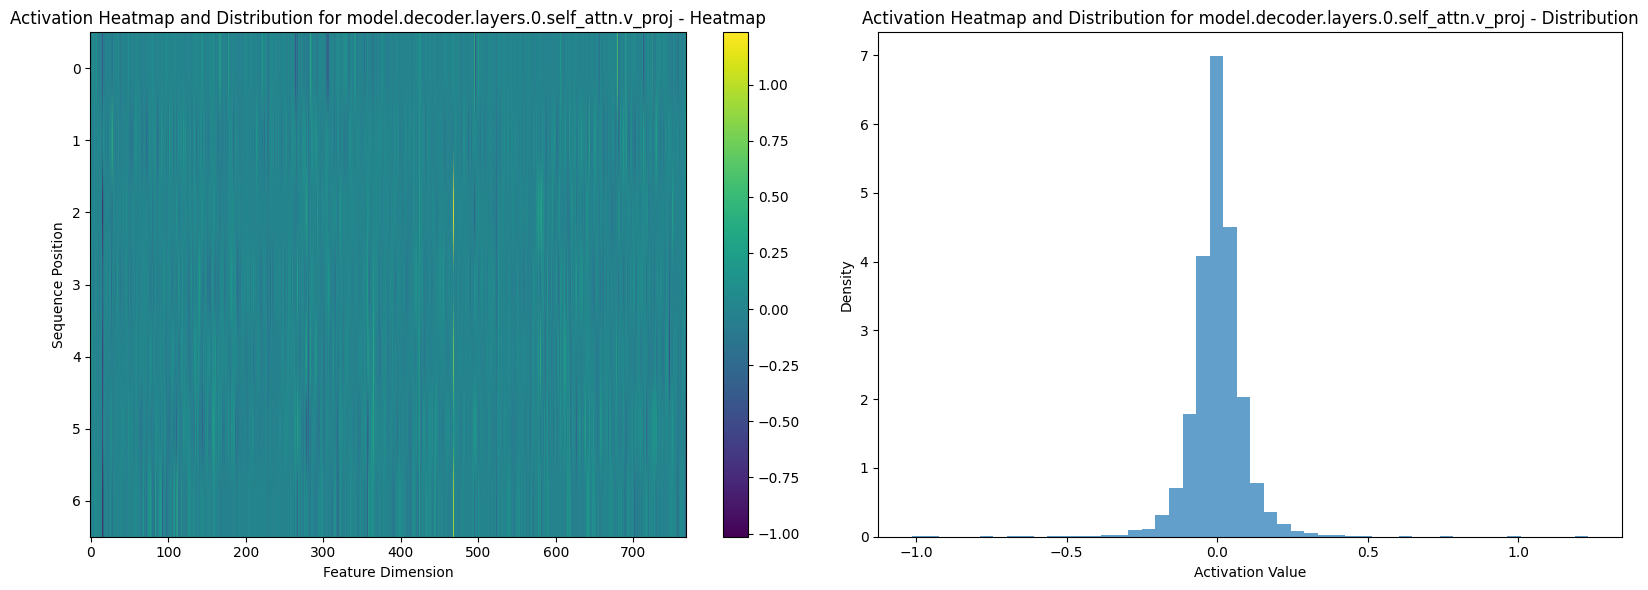

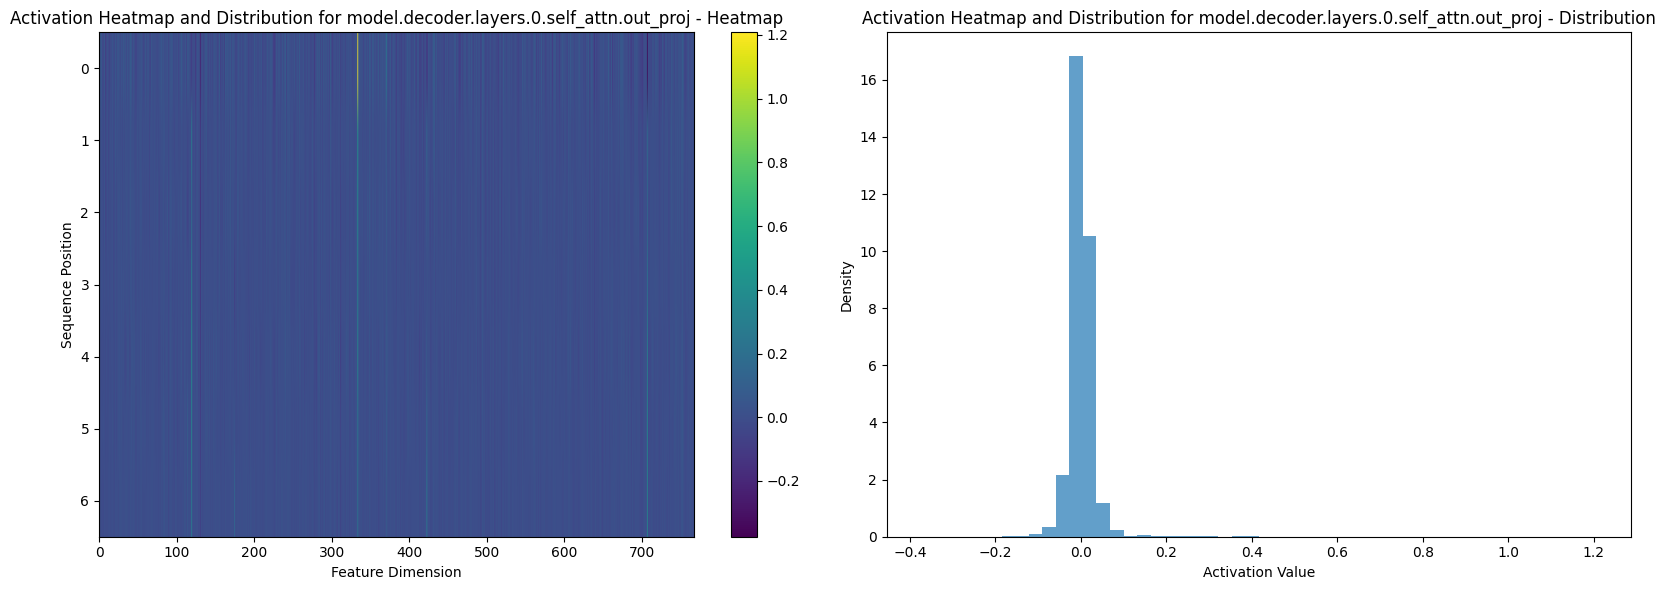

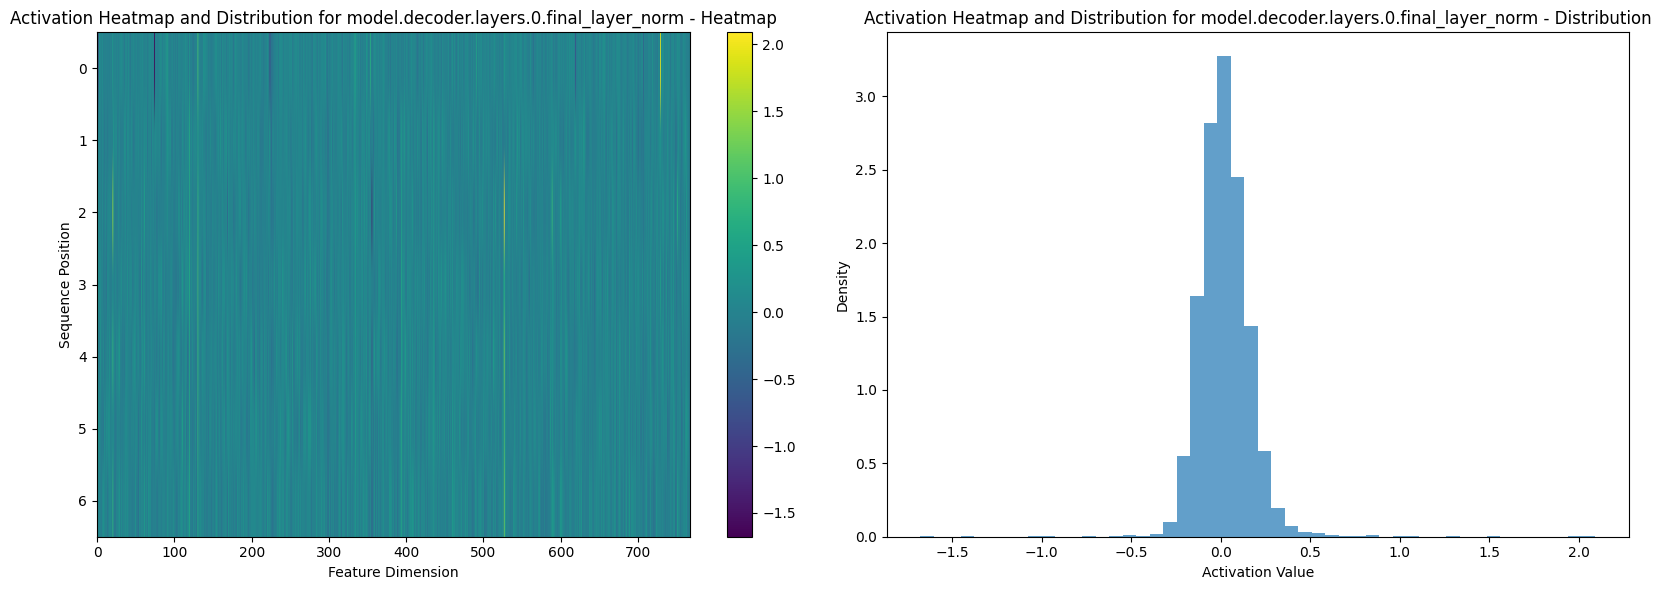

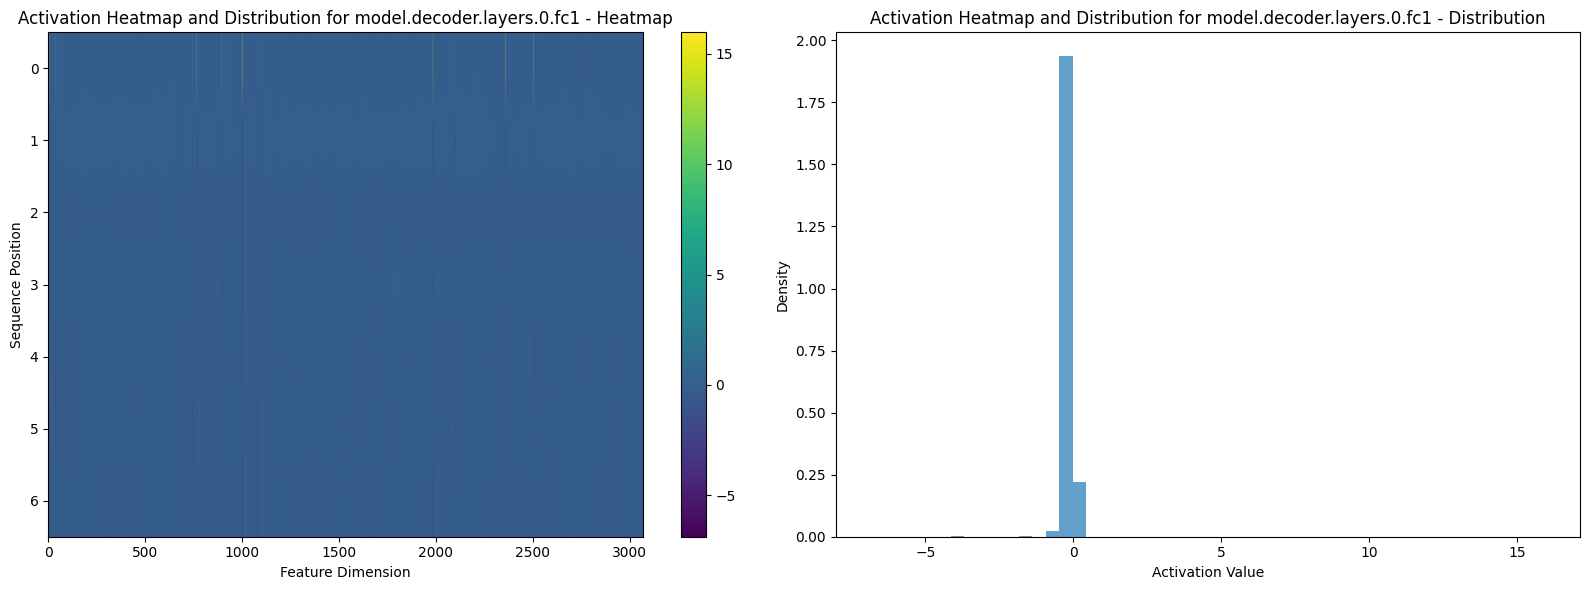

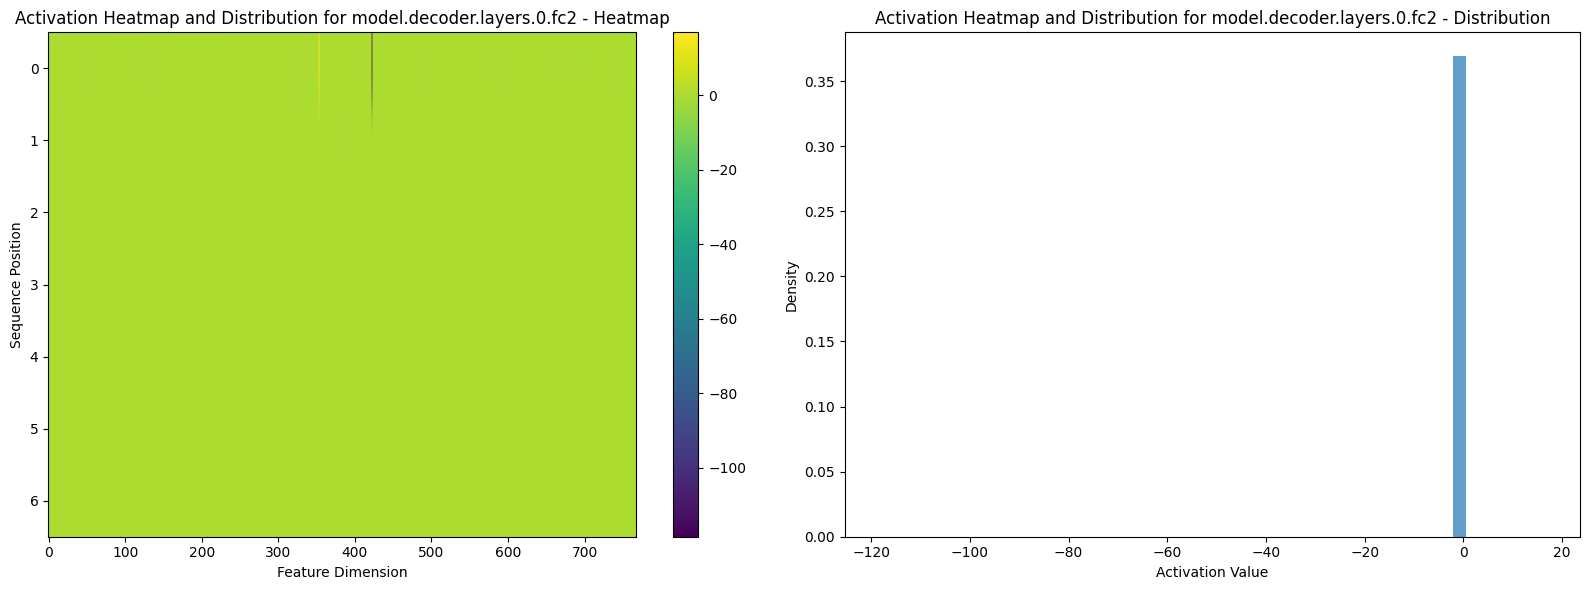

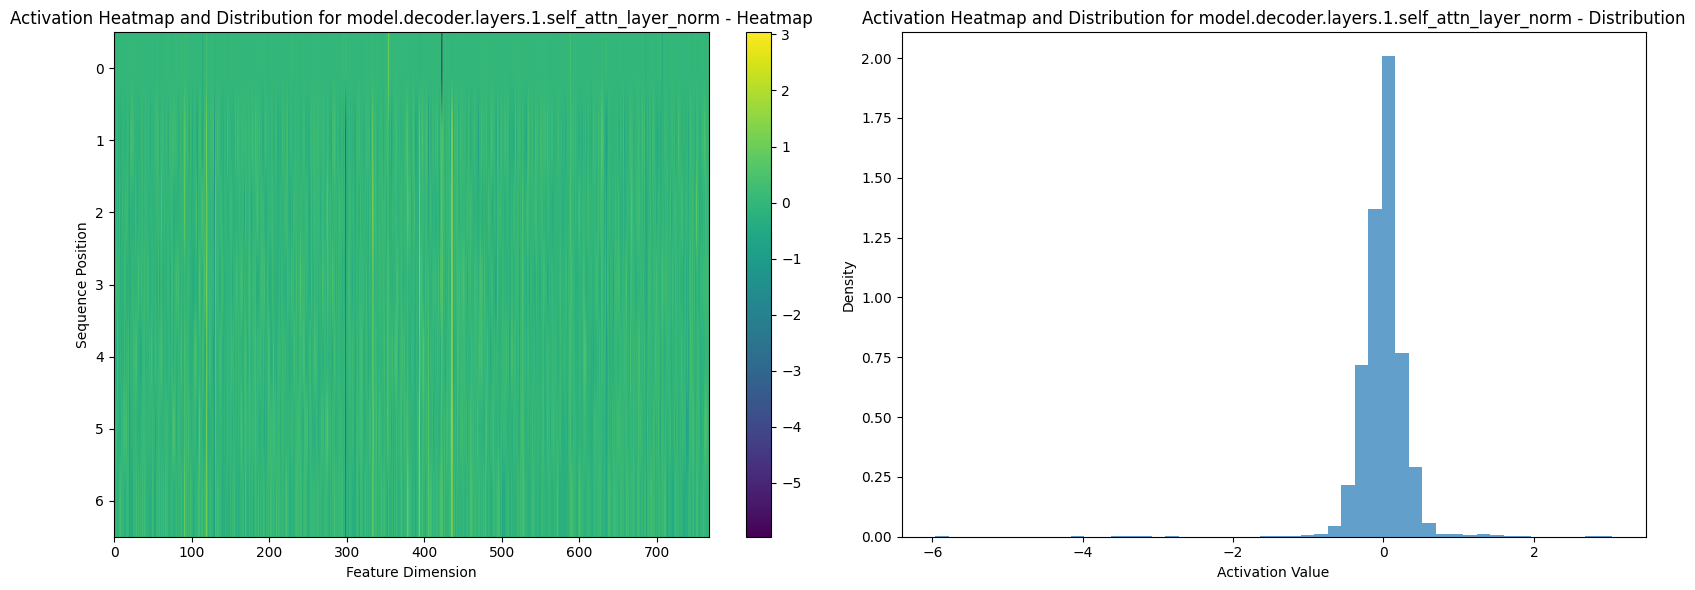

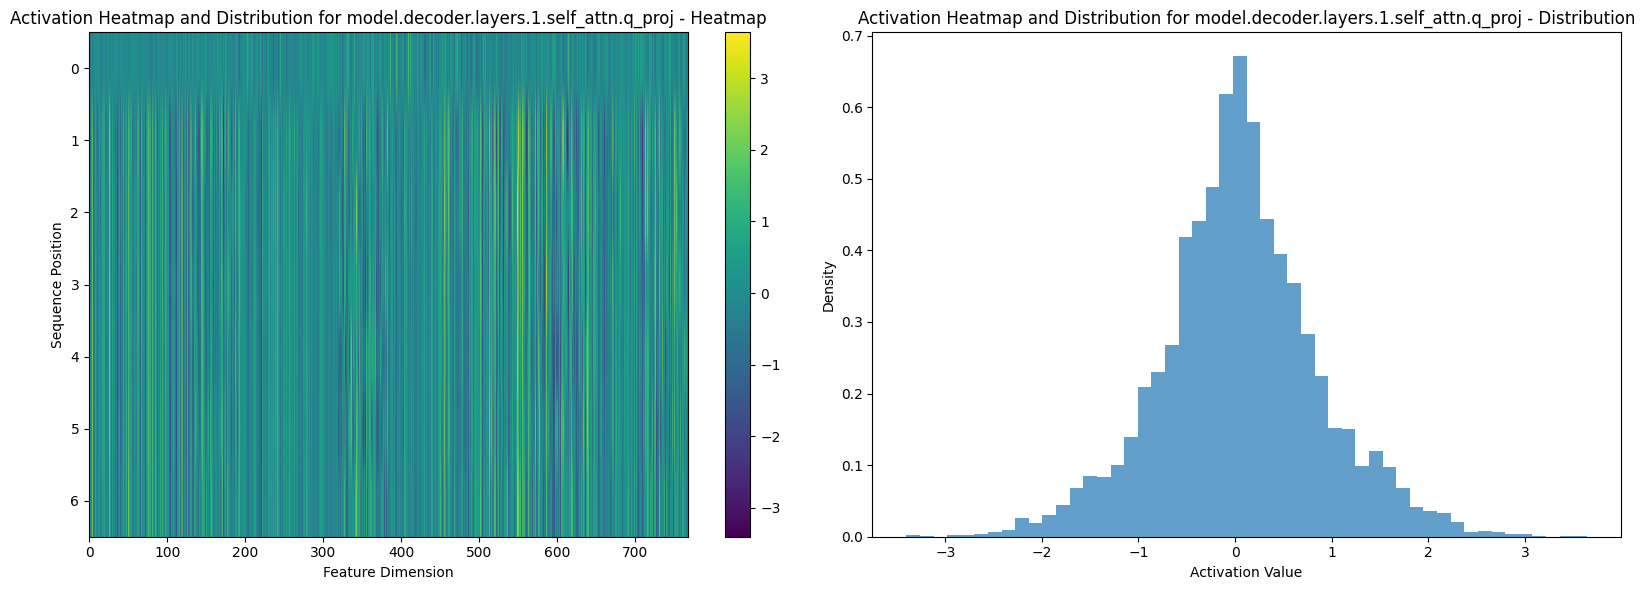

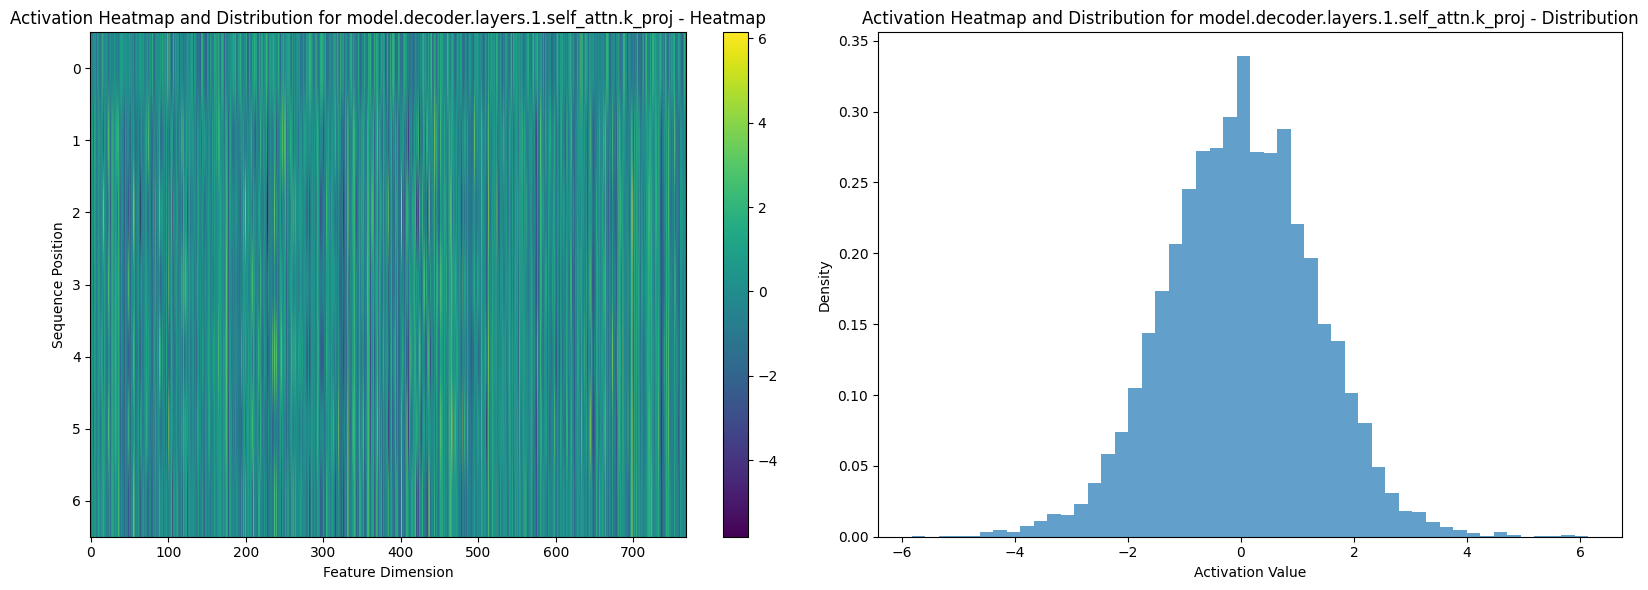

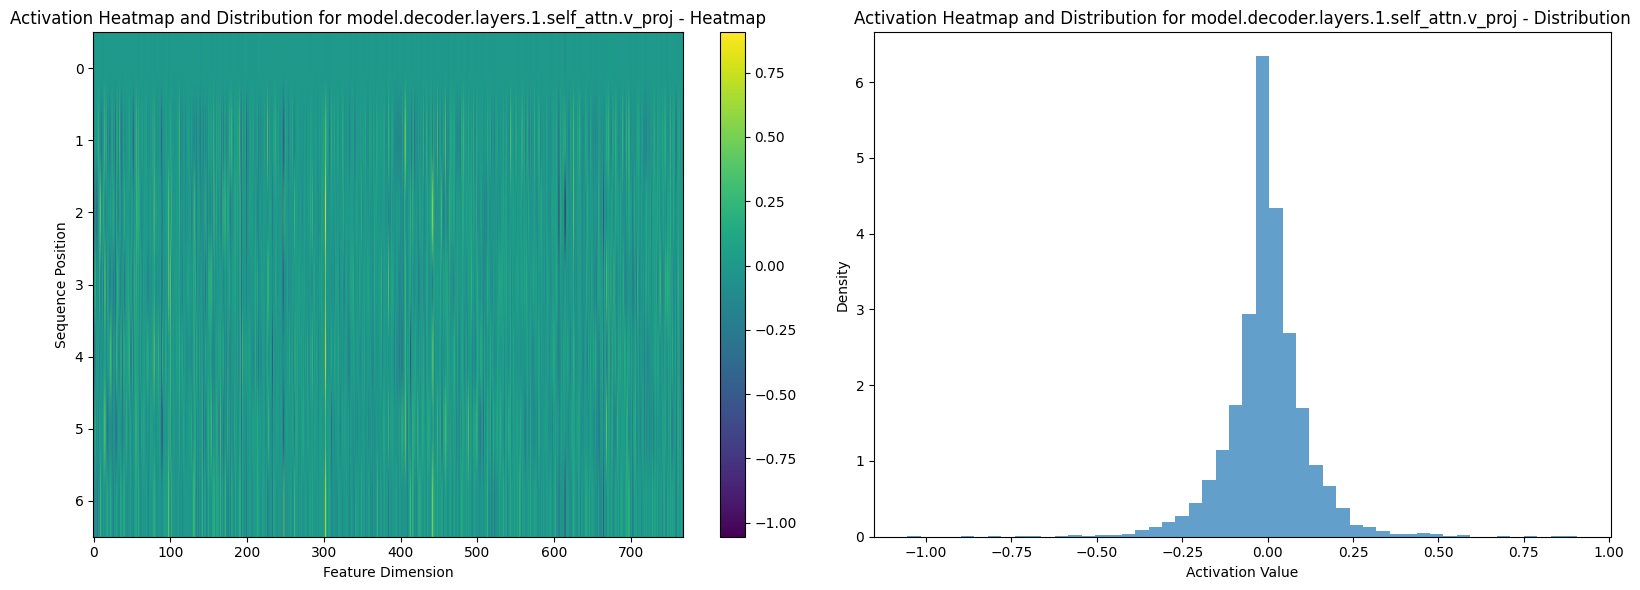

In [ ]:
def plot_activation_heatmap_and_distribution_side_by_side(
    activation_tensor, title: str = None
) -> None:
    """
    Plot a heatmap and a distribution histogram of an activation tensor side by side.

    Args:
        activation_tensor: PyTorch tensor of activations
        title: Title for the plot
    """
    
    ### To Complete ###
    # Convert to numpy arrays for plotting
    if len(activation_tensor.shape) > 2:
        activation_np_2d = activation_tensor.squeeze(0).numpy()
    else:
        activation_np_2d = activation_tensor.numpy()
    activation_np_1d = activation_tensor.flatten().numpy()

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap
    im = axes[0].imshow(activation_np_2d, cmap="viridis", aspect="auto")
    fig.colorbar(im, ax=axes[0])
    axes[0].set_title(f"{title} - Heatmap" if title else "Activation Heatmap")
    axes[0].set_xlabel("Feature Dimension")
    axes[0].set_ylabel("Sequence Position")

    # Distribution
    axes[1].hist(activation_np_1d, bins=50, density=True, color="tab:blue", alpha=0.7)
    axes[1].set_title(f"{title} - Distribution" if title else "Activation Distribution")
    axes[1].set_xlabel("Activation Value")
    axes[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()
    ### End of To Complete ###


for i, (layer_name, activation) in enumerate(layer_activations.items()):
    plot_activation_heatmap_and_distribution_side_by_side(
        activation, title=f"Activation Analysis for {layer_name}"
    )
    if i > 10:
        break

### 3.6 Investigating LLM Attention Scores

In this section, you'll systematically examine the attention scores produced by large language models (LLMs) in response to specific input sentences.

**Why is this important?**  
Analyzing attention scores at various layers provides valuable insight into how the model distributes its focus across different tokens in the input. This understanding is crucial for interpreting model behavior, diagnosing issues, and optimizing architectures for efficiency and performance.

**Your tasks:**
1. **Implement an attention score collection utility:**  
   Write a class-based utility that processes a given input sentence through a loaded LLM and records the attention scores at each relevant layer.
2. **Apply your utility to multiple models and prompts:**  
   Use your class to extract and compare attention score statistics across several LLMs and input sentences. This will help you observe how different architectures and prompts influence attention patterns.

**Key questions to answer as you explore:**
- What is the shape of the attention scores at each layer?
- How do attention patterns differ between models, layers, and input sentences?
- What do these differences suggest about the models' internal mechanisms?

In [ ]:
def collect_attention_scores(model, tokenizer, prompt):
    """
    Collect attention scores from all layers when processing a prompt.

    Args:
        model: The transformer model
        tokenizer: The tokenizer to use
        prompt: Input text prompt

    Returns:
        Dictionary mapping layer names to attention score tensors
    """
    attention_scores = {}

    ### To Complete ###
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model(**inputs, output_attentions=True)
    for layer_idx, attention_layer in enumerate(outputs.attentions):
        layer_name = f"layer_{layer_idx}_attention"
        attention_scores[layer_name] = (
            attention_layer.detach().cpu()
        )  # Shape: (batch_size, num_heads, sequence_length, sequence_length)
    ### End of To Complete ###

    return attention_scores


attention_scores = collect_attention_scores(model, tokenizer, prompt)
# Print attention score shapes for each layer
for layer_name, attention_score in attention_scores.items():
    print(f"{layer_name}: {attention_score.shape}")

layer_0_attention: torch.Size([1, 12, 7, 7])
layer_1_attention: torch.Size([1, 12, 7, 7])
layer_2_attention: torch.Size([1, 12, 7, 7])
layer_3_attention: torch.Size([1, 12, 7, 7])
layer_4_attention: torch.Size([1, 12, 7, 7])
layer_5_attention: torch.Size([1, 12, 7, 7])
layer_6_attention: torch.Size([1, 12, 7, 7])
layer_7_attention: torch.Size([1, 12, 7, 7])
layer_8_attention: torch.Size([1, 12, 7, 7])
layer_9_attention: torch.Size([1, 12, 7, 7])
layer_10_attention: torch.Size([1, 12, 7, 7])
layer_11_attention: torch.Size([1, 12, 7, 7])


Now that we can collect the attention scores from the model, it's valuable to visualize these scores to better understand how the model distributes its focus across the input sequence. Visualizing the attention patterns can reveal structural insights about how information flows within the model.

**Your tasks:**
1. **Develop an attention visualization utility:**  
   Create a class-based utility that, given a model, a module name, and an input prompt, generates:
   - A heatmap of the absolute values of the attention scores for a selected layer and head.

2. **Apply your utility to multiple LLMs and input prompts:**  
   Use your class to extract and compare attention visualizations across several LLMs and a variety of input sentences. This will help you observe whether there are any consistent patterns in the attention or notable differences between models or prompts.

**Key questions to consider as you explore:**
- Do the attention heatmaps reveal any structure or recurring patterns?
- How do attention patterns differ between models, layers, and input sentences?

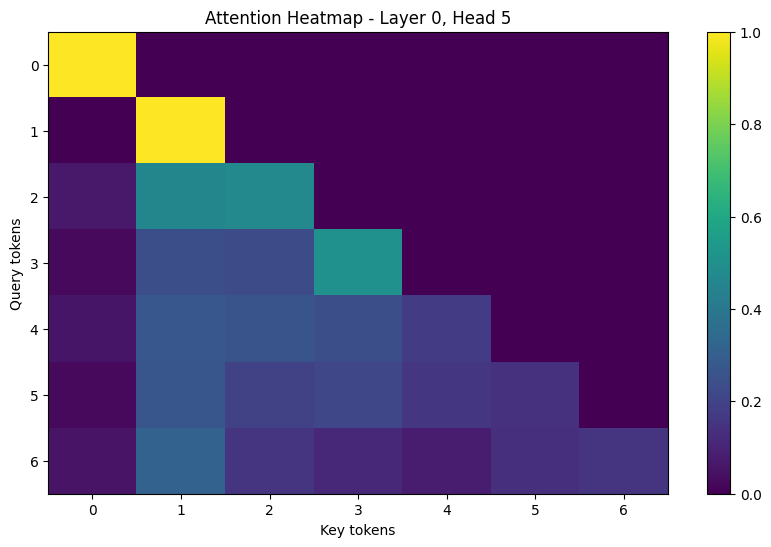

In [ ]:
def plot_attention_heatmap(attention_scores, layer_idx=0, head_idx=0):
    """
    Plot attention heatmap for a specific layer and attention head.

    Args:
        attention_scores: Dictionary of attention scores from collect_attention_scores()
        layer_idx: Index of the transformer layer to visualize (default: 0)
        head_idx: Index of the attention head to visualize (default: 0)
    """

    ### To Complete ###
    layer_name = f"layer_{layer_idx}_attention"
    attention_matrix = attention_scores[layer_name][
        0, head_idx
    ].numpy()  # Get first batch, selected head

    # Plot heatmap
    plt.figure(figsize=(10, 6))
    plt.imshow(attention_matrix, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(f"Attention Heatmap - Layer {layer_idx}, Head {head_idx}")
    plt.xlabel("Key tokens")
    plt.ylabel("Query tokens")
    plt.show()
    ### End of To Complete ###


plot_attention_heatmap(attention_scores, layer_idx=0, head_idx=5)

## Conclusion: What We've Learned About LLM Architectures

In this module, we explored the inner workings of large language models (LLMs) by analyzing their architectures, parameters, and attention mechanisms. Here’s a recap of the key concepts and skills you’ve developed:

- **Model Architecture Exploration:**  
  You learned how to load and inspect the structure of popular LLMs, examining their layers, embedding sizes, and attention mechanisms.

- **Parameter Analysis:**  
  We broke down the parameter counts for different components, helping you understand where most of the model’s capcacity and memory load resides.

- **Attention Analysis:**  
  You built utilities to extract and visualize attention scores, revealing how LLMs focus on different parts of the input. This provided insight into the interpretability and behavior of transformer models. It also hint about what can be the compute load of the attention mechanism.

- **Comparative Analysis:**  
  By comparing attention patterns across models and prompts, you gained intuition about how architectural choices and data affect model behavior.

### Next Steps: Optimizing LLM Efficiency

Now that you understand the foundations of LLM architectures, the next segment will focus on **optimizing LLM efficiency**. You’ll learn about quantization, pruning, distillation, and other techniques to make LLMs faster and more resource-efficient—crucial for real-world deployment.

👉 **Continue to the next notebook:**  
[02-optimizing_llm_efficiency.ipynb on GitHub](https://github.com/PrunaAI/ai-efficiency-courses)

## ⭐ Bonus Exercise: Analyzing Quantized Models

As a bonus, try applying your analysis tools to a **quantized model**. Quantization can dramatically reduce model size and inference cost—see if you can spot any differences in architecture or attention patterns! 

You can find ready-to-use Pruna [quantized models on Hugging Face](https://huggingface.co/models?other=bitsandbytes&sort=trending&search=pruna).



**Your tasks:**
1. **Load a quantized model:**  
   Load a quantized model and apply your analysis tools to it.
2. **Compare quantized and non-quantized models:**  
   Compare the results of your analysis between the quantized and non-quantized models.

**Questions:**
- What are the differences in the architecture of the quantized and non-quantized models?